In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('../data/Call-Center-Dataset.xlsx')
df.shape

(5000, 9)

In [3]:
df.head()

,Call Id,Date,Agent,Department,Answered (Y/N),Resolved,Speed of Answer,AvgTalkDuration,Satisfaction rating
0,ID0001,2015-01-01 09:12:58.000,Diane,Washing Machine,Y,Y,109.0,00:02:23.210000,3.0
1,ID0002,2015-01-01 09:12:57.600,Becky,Air Conditioner,Y,N,70.0,00:04:02.323000,3.0
2,ID0003,2015-01-01 09:47:31.200,Stewart,Washing Machine,Y,Y,10.0,00:02:11.202000,3.0
3,ID0004,2015-01-01 09:47:31.200,Greg,Washing Machine,Y,Y,53.0,00:00:37.481000,2.0
4,ID0005,2015-01-01 10:00:28.800,Becky,Toaster,Y,Y,95.0,00:01:00.083000,3.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Call Id              5000 non-null   str           
 1   Date                 5000 non-null   datetime64[us]
 2   Agent                5000 non-null   str           
 3   Department           5000 non-null   str           
 4   Answered (Y/N)       5000 non-null   str           
 5   Resolved             5000 non-null   str           
 6   Speed of Answer      4054 non-null   float64       
 7   AvgTalkDuration      4054 non-null   object        
 8   Satisfaction rating  4054 non-null   float64       
dtypes: datetime64[us](1), float64(2), object(1), str(5)
memory usage: 351.7+ KB


In [5]:
df[df['Answered (Y/N)']=='N'].shape[0]

946

In [6]:
df['Date'].min(),df['Date'].max()

(Timestamp('2015-01-01 09:12:57.600000'),
 Timestamp('2015-03-31 17:39:50.400000'))

In [7]:
df['date_only']=df['Date'].dt.date
df['hour']=df['Date'].dt.hour
df['day_of_week']=df['Date'].dt.day_name()
df['week_number']=df['Date'].dt.isocalendar().week

In [8]:
df[['Date','date_only','hour','day_of_week','week_number']].head()

,Date,date_only,hour,day_of_week,week_number
0,2015-01-01 09:12:58.000,2015-01-01,9,Thursday,1
1,2015-01-01 09:12:57.600,2015-01-01,9,Thursday,1
2,2015-01-01 09:47:31.200,2015-01-01,9,Thursday,1
3,2015-01-01 09:47:31.200,2015-01-01,9,Thursday,1
4,2015-01-01 10:00:28.800,2015-01-01,10,Thursday,1


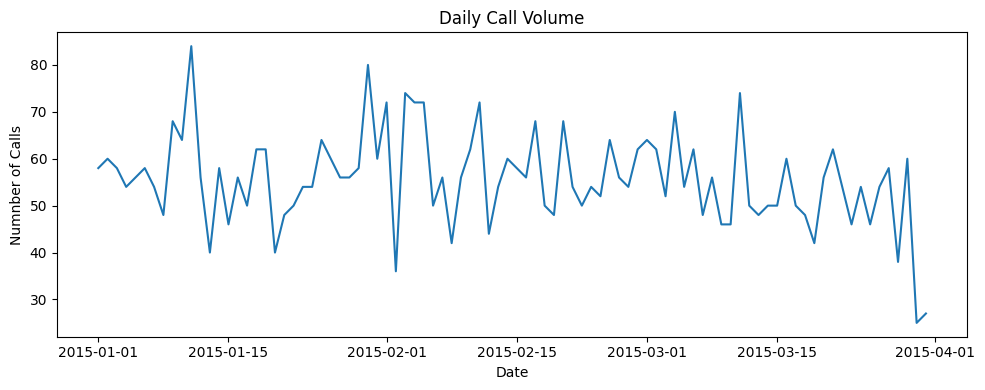

In [9]:
daily_volume= df.groupby('date_only').size()
daily_volume.plot(figsize=(10,4),title='Daily Call Volume')
plt.xlabel('Date')
plt.ylabel('Numnber of Calls')
plt.tight_layout()
plt.show()

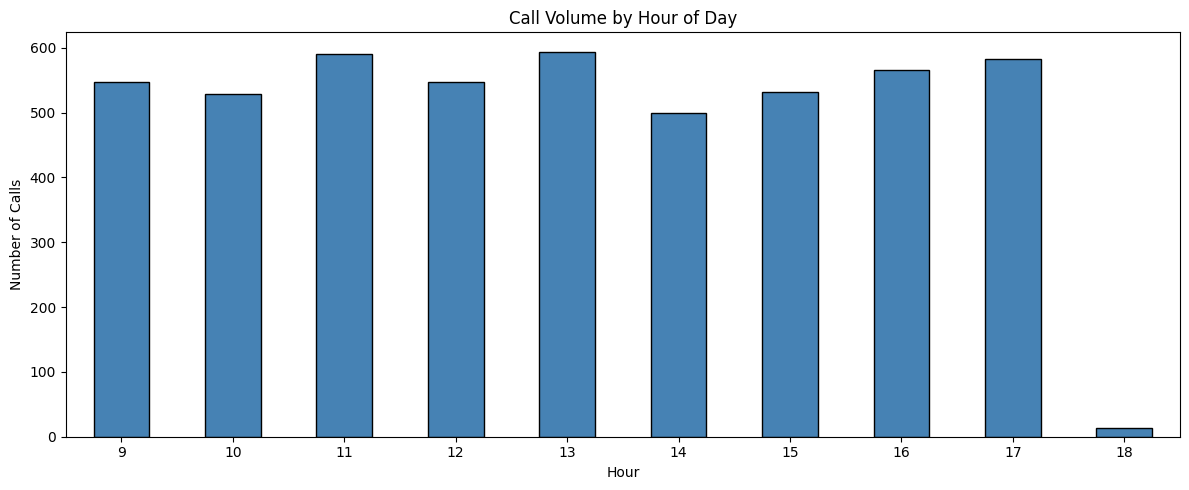

In [13]:
hourly_volume=df.groupby('hour').size()

plt.figure(figsize=(12,5))
hourly_volume.plot(kind='bar', color='steelblue',edgecolor='black')
plt.title('Call Volume by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Hourly Volume Insight
- Operating hours: 9:00 - 17:00 (hour 18 has negligible volume)
- Relatively flat distribution (~500-595 calls per hour)
- Slight peaks at 11:00 and 13:00
- Post-lunch dip at 14:00 (499 calls) — common in contact centers
- No extreme peaks = staffing requirements won't vary dramatically by hour

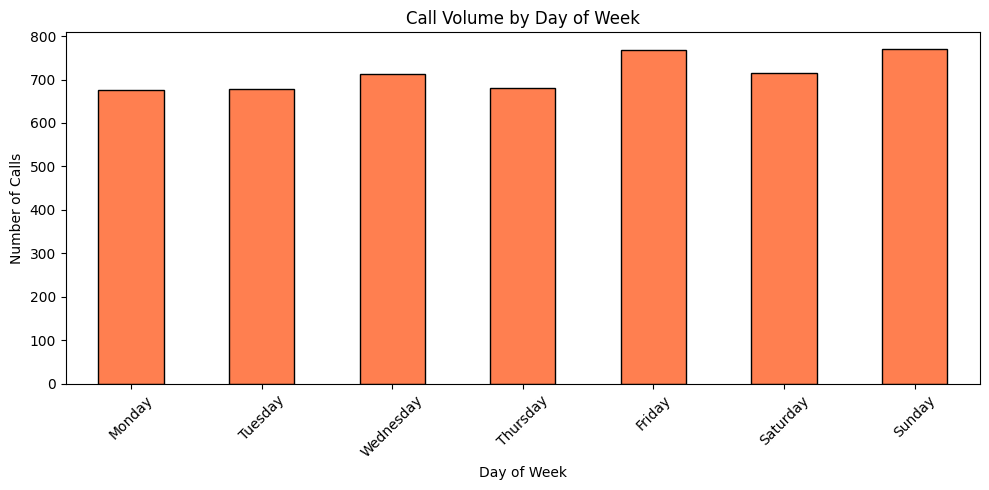

In [14]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_volume = df.groupby('day_of_week').size()
dow_volume = dow_volume.reindex(day_order)

plt.figure(figsize=(10, 5))
dow_volume.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Call Volume by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Calls')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Day of Week Insight
- All 7 days active (this is a 7-day operation)
- Very flat distribution: 675 (Monday) to 770 (Sunday)
- Only 95-call spread across the week (~14% variation)
- No strong day-of-week effect — unlike typical contact centers where Monday is heaviest
- Limitation: this reduces the value of day-of-week as a forecast feature